In [1]:
%reset -f

# Endogeneity and Instrumental Variables

## What is Endogeneity?
Why can't we just run a regression and claim that $\beta$ represents a causal effect and not just a correlation? 

This is a (if not the) key question in econometrics. I mentioned in the previous notebook that we can simply ignore the error, $u$ or $\varepsilon$, when we estimate via ols because the expectation of that error is zero (because we assume $u$ ~ $N(0,1)$ i.e. a mean of zero). However, what happens if that expectation if not zero? Well the estimates for $\beta$ become biased. To unpack why, it is helpful to go through an example.

The cannonical example to describe this in econometrics is the unmeasured "ability" bias. But to avoid being ableist, let's choose another problematic example to explore, what impact do institutions have on ecomomic growth? 

On it's face an interesting question, and you might think we can just run a regression of a measure of intstitutions on GDP per capita see if the coefficient is positive and statistically significant and then we're done. 

However, how do we know this (theoretically) positive coefficient is because good economic institutions lead to higher growth, or higher economic growth lead to good institutions? Which one comes first? 

Well, it's uncertain because both are likely a function of each other i.e. in a simple system of equations where $G = GDP$, $Z = Institutions$ and $X$ contains extra covariates, we have:


$$
G = \theta_1 X + \gamma_1 Z + u 
$$
$$
Z = \theta_2 X + \gamma_2 G + v
$$

In this system, both $G$ and $Z$ are functions of each other. If $Z$ is correlated to $u$ in the first regression, then that little assumption we had when estimating $\beta$ via ols means that the average of $u$, will not be zero. 

This might not seem very intutative at first. But, we can actually show what this bias will look like by decomposing the OLS estimate. Say we simpify the above system of equations into matrix form where the outcome variables are in $Y=[G',Z']$, $\beta$ is a matrix containing all the coefficients $(\theta_i ,  \gamma_i  \forall i )$, $K$ is a square matrix containing all covarites $[[X',Z'],[X',G']]$ and the errors are in $\varepsilon = [u',v]$, then we get this (hopefully that looks familiar):

$$ Y = \beta K  + \varepsilon$$'

We know we can estimate $\beta$ as:

$$ \hat \beta = (K' K)^{-1} K'Y$$

At this point we can substitute the equation back in to $G$ as such:

$$ \hat \beta = (K' K)^{-1}K'(\beta K  + \varepsilon)$$

can be further decomposed to by expanding the brackets:

$$ \hat \beta = (K' K)^{-1}(K'K)\beta + (K' K)^{-1}K'\varepsilon$$


Now you might notice that $(K' K)^{-1}(K'K)$ cancels out because it is an identity matrix, such that the OLS estimate can be simpified to:

$$ \hat \beta = \beta +  (K' K)^{-1}K'\varepsilon$$

So the ols esitmate of $\beta$ is the true population parameter of $\beta$ plus some new term $(K' K)^{-1}K'\varepsilon$. 

Now, this is where the (potential) bias that is added to the esitmate comes from. It arises if the errors and covariates are correlated!

So if $E(\varepsilon | K) \neq 0$ then $(K' K)^{-1}K'\varepsilon \neq 0$, and hence the estimate of $\beta$ will be biased by the magnitude of this term. This is endogeneity bias.

Because we know from the system of equations above that the errors are correlated to the covariates (they're literally equations of each other), we know that the esimates will be biased. Hence, we can't just run a regression of $GDP$ on a measure of $institutions$ and assume it's causal. It will be biased. 

The above example is from a simultenaeity bias, but omitted variable bias and measurement error can also cause endogeneity. 

One of the key conditions for causality to be meet is a source of exogenous variation. Exogeneity means from outside the system and can be thought of as the inverse of endogeneity. As mentioned in the previous notebook, this is a key problem that most econometrics tries to solve. 

## Using instruments to control for endogeneity

There are actually a lot of ways to fix endogeneity. However, for our purposes today we will look at a relatively famous (or infamous) example from the paper: *“The colonial origins of comparative development: An empirical investigation”*, by Daron Acemoglu, Simon Johnson, and James A. Robinson. Here is the AEA link: https://pubs.aeaweb.org/doi/pdfplus/10.1257/aer.91.5.1369. 

In this paper the authors use a method known as **Insturmental Variable** (IV) to control for this simultaneity bias of institutions and economic growth i.e. they solve the problem we've explored above! 

An "*instrument*" basically exploits some source of exogenous variation where there is some partial (or incomplete) random assignment. This allows the instrument to act as a source of randomisation for a specific group of units (known as compliers but maybe more on that later). The source of variation the authors used was euorpean settlers mortality rates at the time of colonisation. 

Because the mortality of settlers is likely related to the types of institutions that were set up during colonisation (think the extractive institutions in the Congo vs. the settler institutions of say Canada), but should be entierly uncorrelated to GDP today (except through the institutions that are set up), this is suggests settler mortality can act as an instrument.

This requires a couple of asusmptions for the instrument to be appropriate. 
- Firstly, the processes of colonisation set up different institutions.
        - i.e. settler cononialism set up inclusive institutions for settlers such as in So-called Australia, Aotearoa / New Zealand or Turtle Island - USA;
        - whilst other colonies set up extractive institutions such as the atlantic slave trade or mita's in Peru
- Seconly, the strategy of colonosiation was dependent on the geographic conditions i.e. lower mortality increased the likliehood of settlers setting up inclusive institutions
- Finally, those colonial institutions that were set up then have persisted today to impact economic performance. 

Therefore, the causal chain follows:

$$ 
settler\ mortality \rightarrow type\ of\ settlements \rightarrow early\ institutions \rightarrow current\ institutions \rightarrow current\ economic\ performance
$$

Okay, a fair enough hypothesis, but how can we use this "instrument" of settler mortality to esitmate an effect? Well let's get into how to estimate an instrumental variable.

## Estimating an Instrumental Variable

Okay let's get some notation down. Typically the instrument is usually represented as $Z$ (a vector containing data on the instrument i.e. settler mortality). Then we usually also have our data on the outcome variable $Y$ (GDP) and other covariates in $X$. Then we have our parameters $\beta$. So we have our typical linear model:

$$ Y = X\beta + \varepsilon$$

Cool, now for the instrument to be introduced. We can add it to this model by multiplting both sides by the instrument:

$$ Z'Y = Z'X\beta + Z'\varepsilon$$

Note that it is transposed to make sure the matrix is square. Now, we can simply solve for $\beta$:

$$ 
\hat\beta_{IV} = (Z'X)^{-1}Z'Y
$$

Okay cool, it looks really similar to OLS but is using the instrument instead. You will notice that the error has falled off again. If we decompose the above estimator we can see why: 

$$ 
\hat\beta_{IV} = (Z'X)^{-1}Z(X\beta + \varepsilon)
$$
$$
\hat\beta_{IV} = (Z'X)^{-1}ZX\beta + (Z'X)^{-1}Z\varepsilon 
$$
$$ 
\hat\beta_{IV} = \beta + (Z'X)^{-1}Z\varepsilon
$$

Now this is where some new assumptions come from to ensure that last pesky bias term dissapears!

To estimate this model we must introduce some key assumptions, namely:
- **Validity** (Strong Instrument | $Cov(Z,\varepsilon)=0$): The instrument $Z$ has strong explanatory power/effect on the variable of interest, $Y$.
- **Relevance** (Independence | $Cov(Z,X)\neq0$): such that the IV randomly assigns or “as good as randomly assigns” individuals to treated or control groups.
- **Exclusion Restriction**: IV only affects outcomes through the variable of interest, $X$, and not through another unobserved mechanism.

Crucially for our estimate to not be biased, the strong instrument assumption must be true i.e. $Cov(Z,\varepsilon)=0$. If there is no relationship between $Z$ and $\varepsilon$ then that bias term will equal zero and the $\beta$ will be an unbiased estiamte. Otherwise, we're back to step one.

Unfortunately, only the exclusion assumption can be directly tested. We can use the $F$-statistic to test for exclusion. If the F-stat is less than 10 the IV estimates suffers from “Weak Instrument bias”. There are some other tests we can look at, but I won't delve to much deeper into them here (This explanation is already getting too long).


Now that we've gone through all that theory - let's replicate the estimates from the paper!

## load all packages

In [2]:
import numpy             as np
import statsmodels.api   as sm
import pandas            as pd
import seaborn           as sns

from linearmodels.iv            import IV2SLS
from statsmodels.iolib.summary2 import summary_col
from collections                import OrderedDict
from linearmodels.iv.results    import compare

## load data
Note that we will only be replicating the estimates from the base population because they are the papers key results. 

However, if you want to try recreate all the papers results, simply remove the filter in the below cell.

In [3]:
df = pd.read_stata("/home/michael/Projects/regression_analysis/data/maketable4.dta")
## only keep base sample - only reproducing some esitmates
df = df[df['baseco'] == 1]

df['oth_cont'] = np.where((df['shortnam'] == "AUS") | 
                          (df['shortnam'] == "MLT") | 
                          (df['shortnam'] == "NZL"), 1,0)

Below is a table describing the data. 
| Name | Label |
| :--- | :--- |
| `shortnam` | 3-letter country name |
| `africa` | Africa |
| `latitude` | Absolute value of latitude |
| `rich4` | ... TBC |
| `avexpr` | Exp Risk |
| `logpgp95` |  Log GDP per capita (PPP) in 1995  |
| `logem4` |  Original Log Settler Mortality  |
| `asia` | Asia |
| `loghjypl` | ... TBC |
| `baseco` | =1 if part of base sample |
| `oth_cont`| =1 if other continent | 

Note that this data was downloaded from a MIT dropbox on 16/6/2026 -https://www.dropbox.com/scl/fi/3yuv9j514zuajzjfluoc1/maketable4.zip?rlkey=pq9l7bxktw1iqxe6fmoh26g79&e=1&dl=0

### Table 2 Column 2
Okay, the very first result we'll replicate is simply the regression of institutions on GDP. 

In our scenario, the measure of institutions adopted is an index of average expropriation risk (an index between 0 and 10). This stands in as a proxy for the types of institutions that were set up (extractive vs inclusive). It is crude but it gets the job done for now. 

Our outcome variable is the log of GDP in 1995 adjusted for purchase price parity. 

Okay, we know how to do this one, we can just throw them into a regression!

In [4]:
# table 2 column 2
m_2_2 = sm.OLS(df['logpgp95'], sm.add_constant(df['avexpr'])).fit()
print(m_2_2.summary())

                            OLS Regression Results                            
Dep. Variable:               logpgp95   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     72.82
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           4.72e-12
Time:                        17:21:18   Log-Likelihood:                -68.168
No. Observations:                  64   AIC:                             140.3
Df Residuals:                      62   BIC:                             144.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6604      0.409     11.408      0.0

Okay, so we see the coefficient is around 0.52. Or in words, an increase in the risk of expropriation index by one point, results in an approximately 0.52% increase in GDP in 1995 *(thanks to the log transformation)*.

Okay, cool this is a helpful baseline for us to test if the IV is working. We know this estimate is likely biased, so we should expect the IV estimate to be quite different. 

We can see in the plot below the above model fit to the data - recreating figure 2 in the paper.

<Axes: xlabel='avexpr', ylabel='logpgp95'>

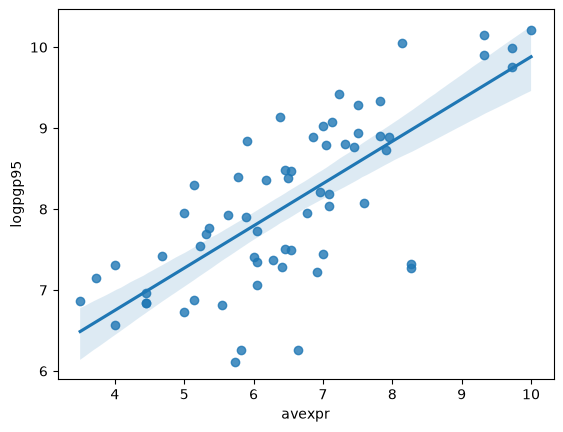

In [5]:
#figure 1
sns.regplot(y='logpgp95',
               x='avexpr',
               data = df)

### Table 4 Panel B Column 1

Okay then next little thing we need to explore is a test for the exclusion assumption. We can do this by running the first stage of the regression i.e. `avexpr ~ logem4`. 

We can then use the $F$ test to see if the instrument suffers from weak instrument bias. 

In [6]:
# table 4 Panel B column 1 
m_4_B_1 = sm.OLS(df['avexpr'], sm.add_constant(df['logem4'])).fit()
print(m_4_B_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 avexpr   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     22.95
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           1.08e-05
Time:                        17:21:18   Log-Likelihood:                -104.83
No. Observations:                  64   AIC:                             213.7
Df Residuals:                      62   BIC:                             218.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3414      0.611     15.296      0.0

We can see from the $F$ stat that the statistic is well over 10. This is some good evidence that the instrument doesn't suffer from weak instrument bias. 

The plot below fits the above model - recreating figure 3 from the paper.

<Axes: xlabel='logem4', ylabel='avexpr'>

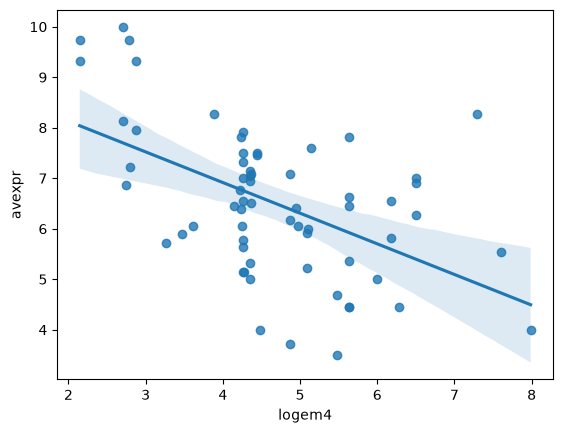

In [7]:
#figure 2
sns.regplot(y='avexpr',
               x='logem4',
               data = df)

### Table 4 Panel A column 1 
Okay now that we've got the testing out of the way, lets us the instrument to estimate the model. 

Handly, the `linearmodels` package in python has a helpful `IV2SLS()` that esimates this approach for us (how lovely). 

Firstly, lets use this function to estimate the simple regression with only the `avexpr` as a dependent variable and `logem4` as the instrument.

*(note i'm using the `baseco` column as the exogenous variable because it is a vector of 1s, but you can use the `sm.add_constant(df)` funtion from statsmodel if you prefer to make sure you estimate the constant variable)*

In [8]:
print(IV2SLS(dependent=df['logpgp95'],
              exog=df['baseco'],
            endog=df[['avexpr']],
            instruments=df[['logem4']]).fit())

                          IV-2SLS Estimation Summary                          
Dep. Variable:               logpgp95   R-squared:                      0.1870
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1739
No. Observations:                  64   F-statistic:                    28.754
Date:                Fri, Jun 19 2026   P-value (F-stat)                0.0000
Time:                        17:21:18   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
baseco         1.9097     1.1740     1.6267     0.1038     -0.3912      4.2106
avexpr         0.9443     0.1761     5.3623     0.00

As upi can see the coefficient has jumped from ~$0.52$ to ... 

### Table 4 Panel A column 7

Next lets create the other two esitmates for column 7 and 8. These estimates add dummy variables for difference continents as well as a measure of absolute latitude.

Firstly, the model with the continent dummy variables:

In [9]:
print(IV2SLS(dependent=df['logpgp95'],
              exog=df[['baseco', 'asia', 'africa', 'oth_cont']],
            endog=df[['avexpr']],
            instruments=df[['logem4']]).fit())

                          IV-2SLS Estimation Summary                          
Dep. Variable:               logpgp95   R-squared:                      0.2286
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1763
No. Observations:                  64   F-statistic:                    36.376
Date:                Fri, Jun 19 2026   P-value (F-stat)                0.0000
Time:                        17:21:18   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
baseco         2.0324     2.1905     0.9278     0.3535     -2.2609      6.3257
asia          -0.9242     0.3705    -2.4947     0.01

Next the model with the continent dummy variables and absolute latitude.

In [10]:
# table 4 Panel B column 8
print(IV2SLS(dependent=df['logpgp95'],
              exog=df[['baseco', 'lat_abst', 'asia', 'africa', 'oth_cont']],
            endog=df[['avexpr']],
            instruments=df[['logem4']]).fit(cov_type='robust'))


                          IV-2SLS Estimation Summary                          
Dep. Variable:               logpgp95   R-squared:                      0.0108
Estimator:                    IV-2SLS   Adj. R-squared:                -0.0745
No. Observations:                  64   F-statistic:                    28.443
Date:                Fri, Jun 19 2026   P-value (F-stat)                0.0000
Time:                        17:21:18   Distribution:                  chi2(5)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
baseco         1.4405     3.0736     0.4687     0.6393     -4.5837      7.4646
lat_abst      -1.1782     1.7917    -0.6576     0.51

Great, those estimate seem to line up with those in the paper. They are also generally quite stable and are all statistically significant. 

Yay. Now the paper does more robustness checks - so feel free to try and replicate this if you like. But for now, let's summarise all these results into a nice table:

In [11]:
# ignore this really uglly code - it makes a pretty table tho
results = OrderedDict()
results['T.2 col 2'] = IV2SLS(dependent=df['logpgp95'], exog=df[['baseco', "avexpr"]], endog=None, instruments= None).fit()
#above is the same as sm.OLS(df['logpgp95'], sm.add_constant(df['avexpr'])).fit()
results['T. 4 Panel B col 1'] = IV2SLS(dependent=df['avexpr'], exog=df[['baseco','logem4']], endog=None, instruments= None).fit()
# above is the same as sm.OLS(df['avexpr'], sm.add_constant(df['logem4'])).fit()
results['T. 4 Panel A col 1'] = IV2SLS(dependent=df['logpgp95'], exog=df['baseco'], endog=df[['avexpr']], instruments=df[['logem4']]).fit()
results['T. 4 Panel A col 7'] = IV2SLS(dependent=df['logpgp95'], exog=df[['baseco', 'asia', 'africa', 'oth_cont']], endog=df[['avexpr']], instruments=df[['logem4']]).fit()
results['T. 4 Panel B col 8'] = IV2SLS(dependent=df['logpgp95'],exog=df[['baseco', 'lat_abst', 'asia', 'africa', 'oth_cont']], endog=df[['avexpr']], instruments=df[['logem4']]).fit()
print(compare(results,precision='std_errors',stars=True))

                                               Model Comparison                                               
                         T.2 col 2 T. 4 Panel B col 1 T. 4 Panel A col 1 T. 4 Panel A col 7 T. 4 Panel B col 8
--------------------------------------------------------------------------------------------------------------
Dep. Variable             logpgp95             avexpr           logpgp95           logpgp95           logpgp95
Estimator                      OLS                OLS            IV-2SLS            IV-2SLS            IV-2SLS
No. Observations                64                 64                 64                 64                 64
Cov. Est.                   robust             robust             robust             robust             robust
R-squared                   0.5401             0.2701             0.1870             0.2286             0.0108
Adj. R-squared              0.5327             0.2584             0.1739             0.1763            -0.0745
F

This is a nice way to easily display the results of each model to easily compare against each other (and isn't to disimilar to the table used in the paper. 

# Instrument Tests

Okay I really didn't go through this, but there are some tests we can use to determine if an IV is a "valid" and or "strong" instrument. 

The alternative hypothesis for all tests is that all the endogenous variables in the model are in fact endogenous. You will see that for all the tests they are infact endogenous - hence all of them result in adopting $H_1$.


Lets test for the IV that has the best adjusted $R^2$, Table 4 Panel A Column 7.

In [12]:
# save the model as an object to call
testing_mod = IV2SLS(dependent=df['logpgp95'], 
                     exog=df[['baseco', 
                              'asia', 
                              'africa', 
                              'oth_cont']], 
                     endog=df[['avexpr']], 
                     instruments=df[['logem4']]).fit()

In [13]:
testing_mod.wu_hausman()

Wu-Hausman test of exogeneity
H0: All endogenous variables are exogenous
Statistic: 11.8774
P-value: 0.0011
Distributed: F(1,58)
WaldTestStatistic, id: 0x74bd4de6b950

In [14]:
testing_mod.durbin()

Durbin test of exogeneity
H0: All endogenous variables are exogenous
Statistic: 10.8784
P-value: 0.0010
Distributed: chi2(1)
WaldTestStatistic, id: 0x74bd4e0a8080

In [15]:
testing_mod.wooldridge_regression

Wooldridge's regression test of exogeneity
H0: Endogenous variables are exogenous
Statistic: 6.5582
P-value: 0.0104
Distributed: chi2(1)
WaldTestStatistic, id: 0x74bd4e0b08f0

In [16]:
testing_mod.wooldridge_score

Wooldridge's score test of exogeneity
H0: Endogenous variables are exogenous
Statistic: 5.4215
P-value: 0.0199
Distributed: chi2(1)
WaldTestStatistic, id: 0x74bd4e0aa2d0

## A note on the paper itself
This paper is often credited as the research the won the 2024 nobel prize in economics. 

I choose this paper because it is quite a clever implementation of instrumental variables and as such is a nice way to introduce people to the concept. 

But that doesn't mean it's without criticism. I will leave a link to some interesting critiques of not just this paper, but the relation of econometrics more broadly towards challenging questions of its relation to colonialism and capitalism: 

- https://theconversation.com/this-years-nobel-prize-exposes-economics-problem-with-colonialism-241400
- https://medium.com/@pedagogyoftheeconomists/economics-has-a-colonialism-problem-a109c5812715